EDA & KPI Insights — Bank Marketing (UCI)

Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load data

In [14]:
df = pd.read_csv("data/bank_marketing.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Quick overview

In [15]:
print("Shape:", df.shape)
df.info()
df.isna().sum().sort_values(ascending=False).head(15)

Shape: (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.id

age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
dtype: int64

Basic cleaning

In [16]:
df = df.drop_duplicates()

# Example: strip spaces in column names
df.columns = [c.strip() for c in df.columns]

df.describe(include="all").T.head()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41176.0,NaN,NaN,NaN,40.0238,10.42068,17.0,32.0,38.0,47.0,98.0
job,41176,12,admin.,10419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41176,4,married,24921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41176,8,university.degree,12164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41176,3,no,32577,NaN,NaN,NaN,NaN,NaN,NaN,NaN


EDA

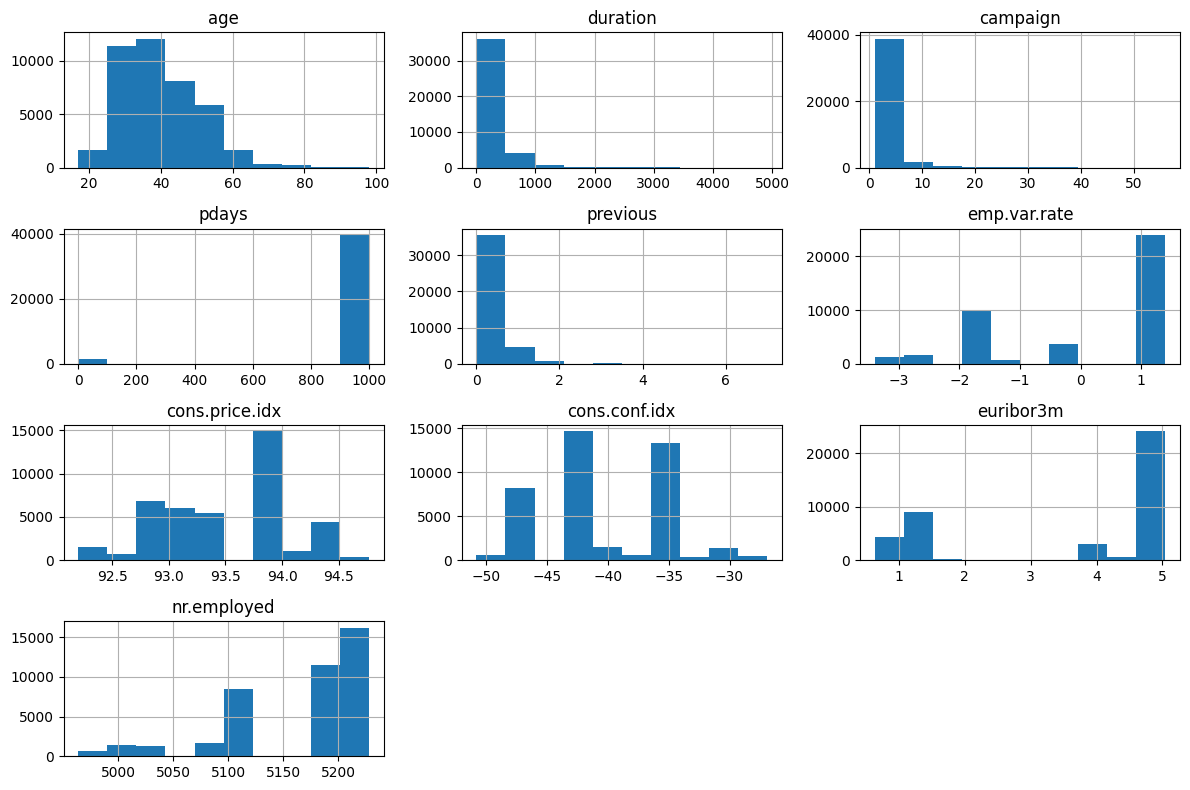

In [17]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

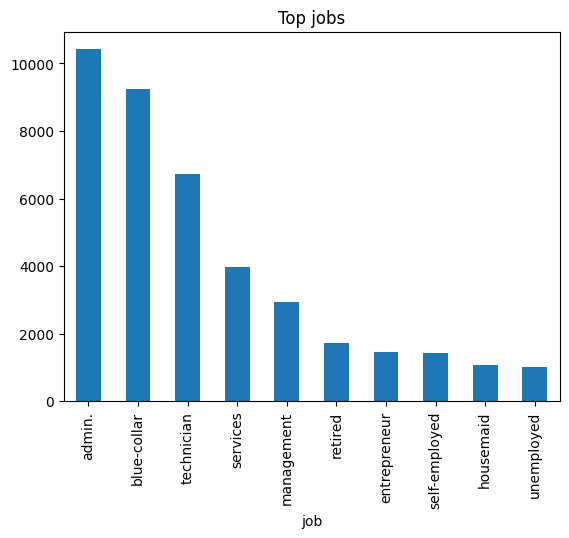

In [18]:
# Example categorical distribution (change 'job' if needed)
df["job"].value_counts().head(10).plot(kind="bar")
plt.title("Top jobs")
plt.show()

KPIs

In [19]:
kpi_total_rows = len(df)
kpi_unique_jobs = df["job"].nunique()
kpi_top_job = df["job"].value_counts().idxmax()

kpi_total_rows, kpi_unique_jobs, kpi_top_job

(41176, 12, 'admin.')

KPIs automáticos en tabla

In [20]:
# --- KPI table (auto) ---
kpis = {
    "Total records": len(df),
    "Unique jobs": df["job"].nunique() if "job" in df.columns else np.nan,
    "Top job group": df["job"].value_counts().idxmax() if "job" in df.columns else np.nan,
}

kpi_table = pd.DataFrame.from_dict(kpis, orient="index", columns=["value"])
kpi_table

,value
Total records,41176
Unique jobs,12
Top job group,admin.


Guardar KPIs en CSV

In [21]:
kpi_table.to_csv("../kpis_summary.csv", index=True)

## Insights (summary)

**Key findings**
- **Segment concentration:** A small number of categories (e.g., top job groups) concentrate a large share of clients, which is useful for prioritizing targeting and messaging.
- **Distribution & skewness:** Numeric variables show skewed distributions/outliers, suggesting the use of robust statistics (median/IQR) and potential transformations before modeling.
- **Behavior differences by segment:** Differences appear when comparing key variables across segments (job/education/marital), which can inform targeting and engagement strategies.

**KPIs**
See the KPI table generated above.

## Next steps
- Add deeper segmentation (e.g., age bands) and compare KPIs across groups.
- Build a baseline classification model and evaluate with Precision/Recall/F1.
- Add a short “executive summary” section with the top 3 insights + visuals.